In [6]:
# prompt: 讀取customer_segmentation_10k.csv

import pandas as pd

df = pd.read_csv('customer_segmentation_10k.csv')
df.head()


,customer_id,qtt_order,total_spent,last_order
0,0,370,189719.04,2022/10/30 07:00
1,1,48,159092.71,2022/6/30 12:00
2,2,4,28239.30,2022/8/21 01:00
3,3,157,378630.99,2022/6/30 04:00
4,4,16,84763.20,2022/3/18 20:00


In [7]:
# prompt: 使用 DataFrame df: 將last_order中資料轉換成至現在（2025、3、31）的天數，新增變數至df

import pandas as pd

# Convert 'last_order' to datetime objects
df['last_order'] = pd.to_datetime(df['last_order'])

# Define the target date
target_date = pd.to_datetime('2025-03-31')

# Calculate the difference in days
df['days_since_last_order'] = (target_date - df['last_order']).dt.days

# Display the updated DataFrame
df.head()


,customer_id,qtt_order,total_spent,last_order,days_since_last_order
0,0,370,189719.04,2022-10-30 07:00:00,882
1,1,48,159092.71,2022-06-30 12:00:00,1004
2,2,4,28239.30,2022-08-21 01:00:00,952
3,3,157,378630.99,2022-06-30 04:00:00,1004
4,4,16,84763.20,2022-03-18 20:00:00,1108


In [8]:
# prompt: 使用 DataFrame df: 請移除空值

# Remove rows with any missing values.
df.dropna(inplace=True)


In [18]:
# prompt: 以 qtt_order、total_spent、days_since_last_order進行DBSCAN分群

from sklearn.cluster import DBSCAN
import numpy as np

# Select features for clustering
X = df[['qtt_order', 'total_spent', 'days_since_last_order']]

# Scale the features (important for DBSCAN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0., min_samples=5) # Adjust eps and min_samples as needed
clusters = dbscan.fit_predict(X_scaled) #產生分群結果

# Add cluster labels to the DataFrame
df['cluster_DBSCAN'] = clusters

print(df.head())
# Analyze the clusters (e.g., count members in each cluster)
print(df['cluster_DBSCAN'].value_counts())

# You can further analyze the clusters by examining the characteristics
# of the data points within each cluster.  For example:
# print(df[df['cluster'] == 0].describe()) # Examine cluster 0
# print(df[df['cluster'] == 1].describe()) # Examine cluster 1
# ... and so on.


   customer_id  qtt_order  total_spent          last_order  \
0            0        370    189719.04 2022-10-30 07:00:00   
1            1         48    159092.71 2022-06-30 12:00:00   
2            2          4     28239.30 2022-08-21 01:00:00   
3            3        157    378630.99 2022-06-30 04:00:00   
4            4         16     84763.20 2022-03-18 20:00:00   

   days_since_last_order  cluster  cluster_DBSCAN  
0                    882        0               0  
1                   1004        0               0  
2                    952        0               0  
3                   1004        0               0  
4                   1108        0               0  
cluster_DBSCAN
 0    9795
-1     185
 3       7
 1       5
 4       5
 2       3
Name: count, dtype: int64


In [21]:
# prompt: 針對以上分群，選擇適當的eps，min_samples值，使分群至少兩群以上

import pandas as pd
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('customer_segmentation_10k.csv')
df.head()



# Convert 'last_order' to datetime objects
df['last_order'] = pd.to_datetime(df['last_order'])

# Define the target date
target_date = pd.to_datetime('2025-03-31')

# Calculate the difference in days
df['days_since_last_order'] = (target_date - df['last_order']).dt.days

# Display the updated DataFrame
df.head()


# Remove rows with any missing values.
df.dropna(inplace=True)



# Select features for clustering
X = df[['qtt_order', 'total_spent', 'days_since_last_order']]

# Scale the features (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN with adjusted parameters
# Experiment with different eps and min_samples values
dbscan = DBSCAN(eps=1.0, min_samples=5)  # Example values; adjust as needed
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df['cluster_DBSCAN'] = clusters

print(df.head())
# Analyze the clusters (e.g., count members in each cluster)
print(df['cluster_DBSCAN'].value_counts())


   customer_id  qtt_order  total_spent          last_order  \
0            0        370    189719.04 2022-10-30 07:00:00   
1            1         48    159092.71 2022-06-30 12:00:00   
2            2          4     28239.30 2022-08-21 01:00:00   
3            3        157    378630.99 2022-06-30 04:00:00   
4            4         16     84763.20 2022-03-18 20:00:00   

   days_since_last_order  cluster_DBSCAN  
0                    882               0  
1                   1004               0  
2                    952               0  
3                   1004               0  
4                   1108               0  
cluster_DBSCAN
 0    9983
-1      17
Name: count, dtype: int64


In [23]:
# prompt: 以 df中 qtt_order、total_spent、days_since_last_order先進行輪廓係數法，找到最佳的k值，再進行K-eans分群

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ... (Your existing code to load and preprocess the data) ...

# Select features for clustering
X = df[['qtt_order', 'total_spent', 'days_since_last_order']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k using silhouette analysis
silhouette_scores = []
for k in range(2, 11):  # Test k from 2 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Silhouette Score for k={k}: {score}")

# Find the optimal k based on the highest silhouette score
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2  # Index + 2 (since k starts at 2)
print(f"Optimal k based on Silhouette Score: {optimal_k}")


# Apply KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Analyze the clusters
print(df['cluster_KMeans'].value_counts())

# Print first few rows of the dataframe with cluster labels
print(df.head())


Silhouette Score for k=2: 0.45377842625641096
Silhouette Score for k=3: 0.4292801145740541
Silhouette Score for k=4: 0.4049609542867182
Silhouette Score for k=5: 0.28646937246610343
Silhouette Score for k=6: 0.2962766136567329
Silhouette Score for k=7: 0.30510215956011705
Silhouette Score for k=8: 0.3150647646872209
Silhouette Score for k=9: 0.3251816451687407
Silhouette Score for k=10: 0.3200424586037553
Optimal k based on Silhouette Score: 2
cluster_KMeans
1    8246
0    1754
Name: count, dtype: int64
   customer_id  qtt_order  total_spent          last_order  \
0            0        370    189719.04 2022-10-30 07:00:00   
1            1         48    159092.71 2022-06-30 12:00:00   
2            2          4     28239.30 2022-08-21 01:00:00   
3            3        157    378630.99 2022-06-30 04:00:00   
4            4         16     84763.20 2022-03-18 20:00:00   

   days_since_last_order  cluster_DBSCAN  cluster_KMeans  
0                    882               0               0  


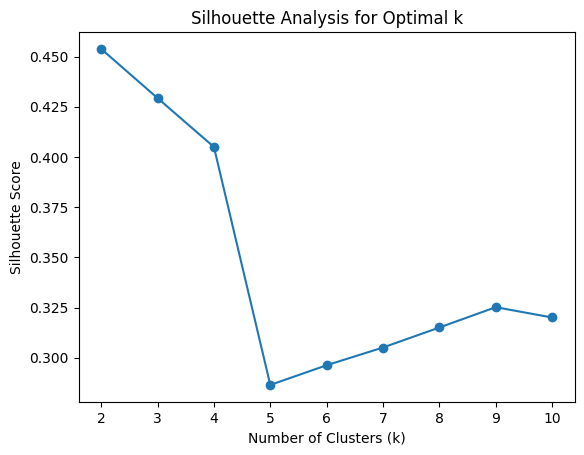

In [22]:
# prompt: 針對以上輪廓係數分析，來作曲綫圖（k v.s.輪廓係數）

import matplotlib.pyplot as plt

# ... (Your existing code) ...

# Find optimal k using silhouette analysis (as in your provided code)
silhouette_scores = []
for k in range(2, 11):  # Test k from 2 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.show()


In [24]:
df.head()

,customer_id,qtt_order,total_spent,last_order,days_since_last_order,cluster_DBSCAN,cluster_KMeans
0,0,370,189719.04,2022-10-30 07:00:00,882,0,0
1,1,48,159092.71,2022-06-30 12:00:00,1004,0,1
2,2,4,28239.30,2022-08-21 01:00:00,952,0,1
3,3,157,378630.99,2022-06-30 04:00:00,1004,0,1
4,4,16,84763.20,2022-03-18 20:00:00,1108,0,1


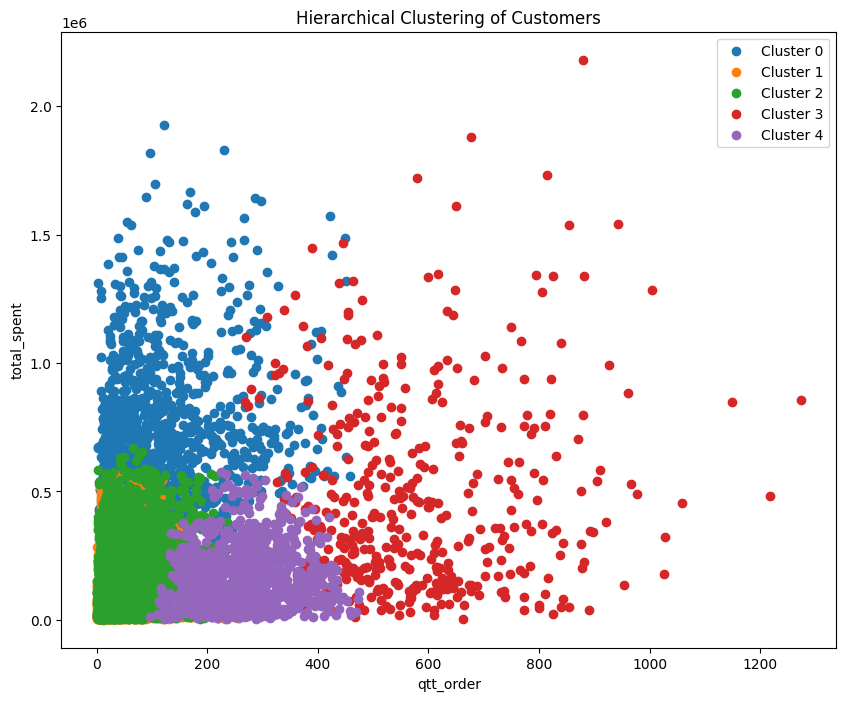

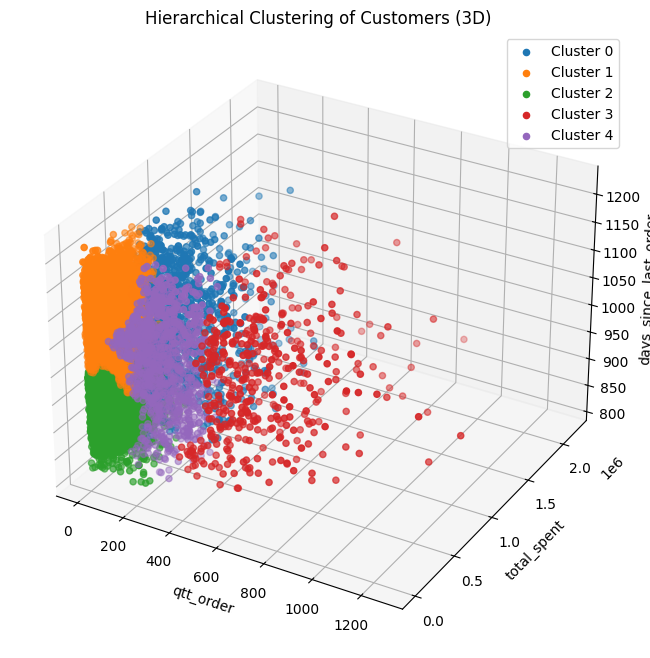

In [34]:
# prompt: 以 df中 qtt_order、total_spent、days_since_last_order進行階層式分群,，都要有，並進行繪圖

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is already loaded and preprocessed as in your original code

# Select features for hierarchical clustering
features = ['qtt_order', 'total_spent', 'days_since_last_order']
X = df[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=5)  # You can adjust the number of clusters
df['cluster_hierarchical'] = agg_clustering.fit_predict(X_scaled)

# Plotting the clusters
plt.figure(figsize=(10, 8))
for cluster in range(5):  # Assuming 5 clusters
    cluster_data = df[df['cluster_hierarchical'] == cluster]
    plt.scatter(cluster_data['qtt_order'], cluster_data['total_spent'], label=f'Cluster {cluster}')

plt.xlabel('qtt_order')
plt.ylabel('total_spent')
plt.title('Hierarchical Clustering of Customers')
plt.legend()
plt.show()


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(5):  # Assuming 5 clusters
    cluster_data = df[df['cluster_hierarchical'] == cluster]
    ax.scatter(cluster_data['qtt_order'], cluster_data['total_spent'], cluster_data['days_since_last_order'], label=f'Cluster {cluster}')

ax.set_xlabel('qtt_order')
ax.set_ylabel('total_spent')
ax.set_zlabel('days_since_last_order')
ax.set_title('Hierarchical Clustering of Customers (3D)')
plt.legend()
plt.show()


In [35]:
df.head()

,customer_id,qtt_order,total_spent,last_order,days_since_last_order,cluster_DBSCAN,cluster_KMeans,cluster_hierarchical
0,0,370,189719.04,2022-10-30 07:00:00,882,0,0,3
1,1,48,159092.71,2022-06-30 12:00:00,1004,0,1,1
2,2,4,28239.30,2022-08-21 01:00:00,952,0,1,2
3,3,157,378630.99,2022-06-30 04:00:00,1004,0,1,4
4,4,16,84763.20,2022-03-18 20:00:00,1108,0,1,1


In [36]:
# prompt: 使用 DataFrame df: 匯出excel，filename：clustering_result

# Export the dataframe to an Excel file named 'clustering_result.xlsx'
df.to_excel('clustering_result.xlsx', index=False) # Set index=False to avoid writing row indices to the file
